# Forward Repetition Access Lag-CRP

> Measure how strongly temporal neighbors cue access to repeated items.

The forward repetition access CRP measures the conditional probability of transitioning *to* an available repeated item as a function of the previous recall's lag from each repeated-item presentation. This is the forward-conditioned counterpart to the clean backward repetition CRP. The focal lags are `+1` and `+2`: transitions from the forward neighbors of the first or second presentation into the repeated item.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.repaccesscrp import (
    plot_rep_access_crp,
    subject_rep_access_crp,
    test_rep_access_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
min_lag = 4
max_lag = 5
size = 2
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


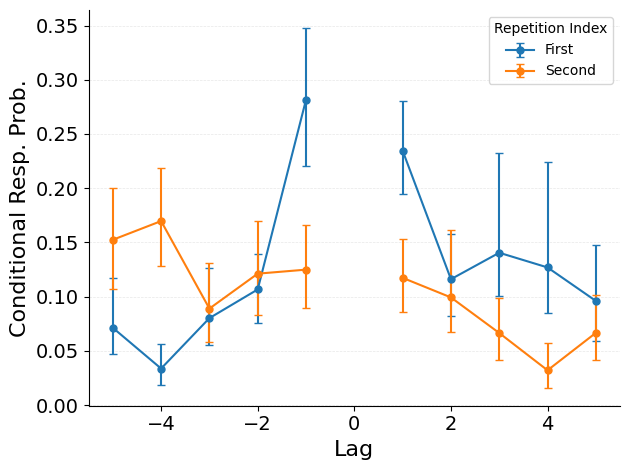

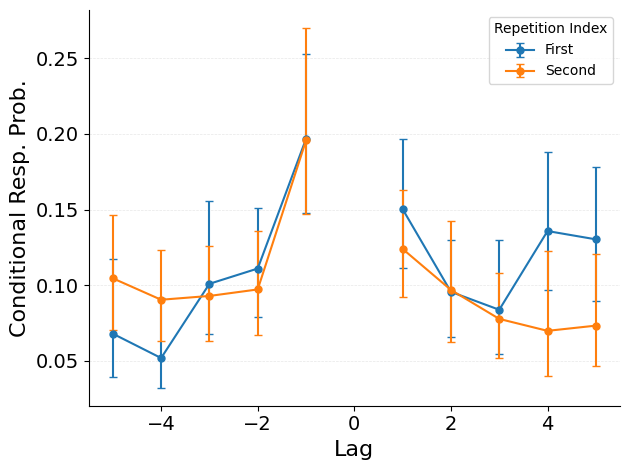

In [4]:
plot_rep_access_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_rep_access_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")

In [5]:
observed_crp = subject_rep_access_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_rep_access_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_rep_access_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)

bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Access Bias (Observed) vs First-Second Access Bias (Control)")
print(f"{'='*70}")
print(bias_result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    0.125     0.9015 |    150.5     0.7467 |     0.0034
   -4 |   -1.008     0.3205 |     92.0     0.4139 |    -0.0181
   -3 |   -0.988     0.3301 |    135.5     0.4674 |    -0.0207
   -2 |   -0.175     0.8618 |    208.0     0.8372 |    -0.0043
   -1 |    2.191     0.0354 |    139.5     0.0335 |     0.0849
    0 |      nan        nan |      nan        nan |        nan
    1 |    2.851     0.0074 |    141.0     0.0074 |     0.0843
    2 |    0.882     0.3838 |    170.0     0.4522 |     0.0205
    3 |    1.523     0.1369 |    133.5     0.0693 |     0.0568
    4 |   -0.302     0.7642 |    164.0     0.3743 |    -0.0089
    5 |   -1.062     0.2956 |    117.0     0.3456 |    -0.0342

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

## Interpretation

Two plots are produced: one for observed (mixed-list) data and one for the shuffled control. Each shows forward access curves by presentation index. Key patterns:

- **Neighbor access**: lags `+1` and `+2` ask whether forward neighbors of a repeated-item presentation cue recall of the repeated item.
- **First vs. second presentation**: differences between curves reveal whether neighbors of one occurrence provide stronger access to the repeated item.
- **Observed vs. control**: differences isolate repetition-specific access beyond shuffled baselines.

## API Details

### Notebook parameters

- `data_path` - path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for the saved figure. Leave empty to display without saving.
- `ylim` - y-axis limits, or `None` for automatic scaling.
- `mixed_trial_query` - query selecting trials with repeated items.
- `control_trial_query` - query selecting trials for the control.
- `control_shuffles` - number of shuffle iterations for building the control dataset.
- `min_lag` - minimum spacing between repeated presentations.
- `max_lag` - maximum absolute lag displayed.
- `size` - maximum number of study positions a single item can occupy.
- `confidence_level` - confidence level for subject-wise error bars.